In [11]:
!pip install gdown  # Ensure gdown is installed

In [12]:
import gdown

# Replace FILE_ID with your actual file ID
file_id = "1pUG3KKu7-fLBulAWD5iufk2oN-VHTsdt"
output_file = "Brain_Tumor_Datasets.zip"

# Download the file
gdown.download(f"https://drive.google.com/uc?id={file_id}", output_file, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1pUG3KKu7-fLBulAWD5iufk2oN-VHTsdt
From (redirected): https://drive.google.com/uc?id=1pUG3KKu7-fLBulAWD5iufk2oN-VHTsdt&confirm=t&uuid=0e8f6438-690c-4792-b481-36b13252d364
To: /content/Brain_Tumor_Datasets.zip
100%|██████████| 32.9M/32.9M [00:00<00:00, 189MB/s]


'Brain_Tumor_Datasets.zip'

In [13]:
import zipfile
z= zipfile.ZipFile('/content/Brain_Tumor_Datasets.zip')
z.extractall()

In [14]:
import numpy as np
import pandas as pd
import os
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import LearningRateScheduler, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

In [15]:
# Set dataset directory paths
train_dir = "Brain_Tumor_Datasets/train"
test_dir = "Brain_Tumor_Datasets/test"

In [16]:
# Initialize the ImageDataGenerator for data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize images to [0, 1]
    validation_split=0.2,  # Set validation split
    rotation_range=20,  # Random rotation between 0 and 20 degrees
    width_shift_range=0.2,  # Random horizontal shift
    height_shift_range=0.2,  # Random vertical shift
    shear_range=0.2,  # Random shear transformations
    zoom_range=0.2,  # Random zoom
    horizontal_flip=True,  # Random horizontal flip
    fill_mode='nearest'  # How to fill in new pixels after transformation
)

# Load training and validation datasets using flow_from_directory
traindata = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # Resize images to (224, 224)
    batch_size=32,
    color_mode='rgb', # Change color_mode to 'rgb'
    class_mode='categorical',  # For integer labels
    shuffle=True
)

# Load training and validation datasets using flow_from_directory
valdata = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # Resize images to (224, 224)
    batch_size=32,
    color_mode='rgb', # Change color_mode to 'rgb'
    class_mode='categorical',
    shuffle=True
)

Found 3598 images belonging to 2 classes.
Found 3598 images belonging to 2 classes.


In [17]:
print(traindata.class_indices)

{'NO': 0, 'YES': 1}


(32, 2)
(32, 224, 224, 3)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


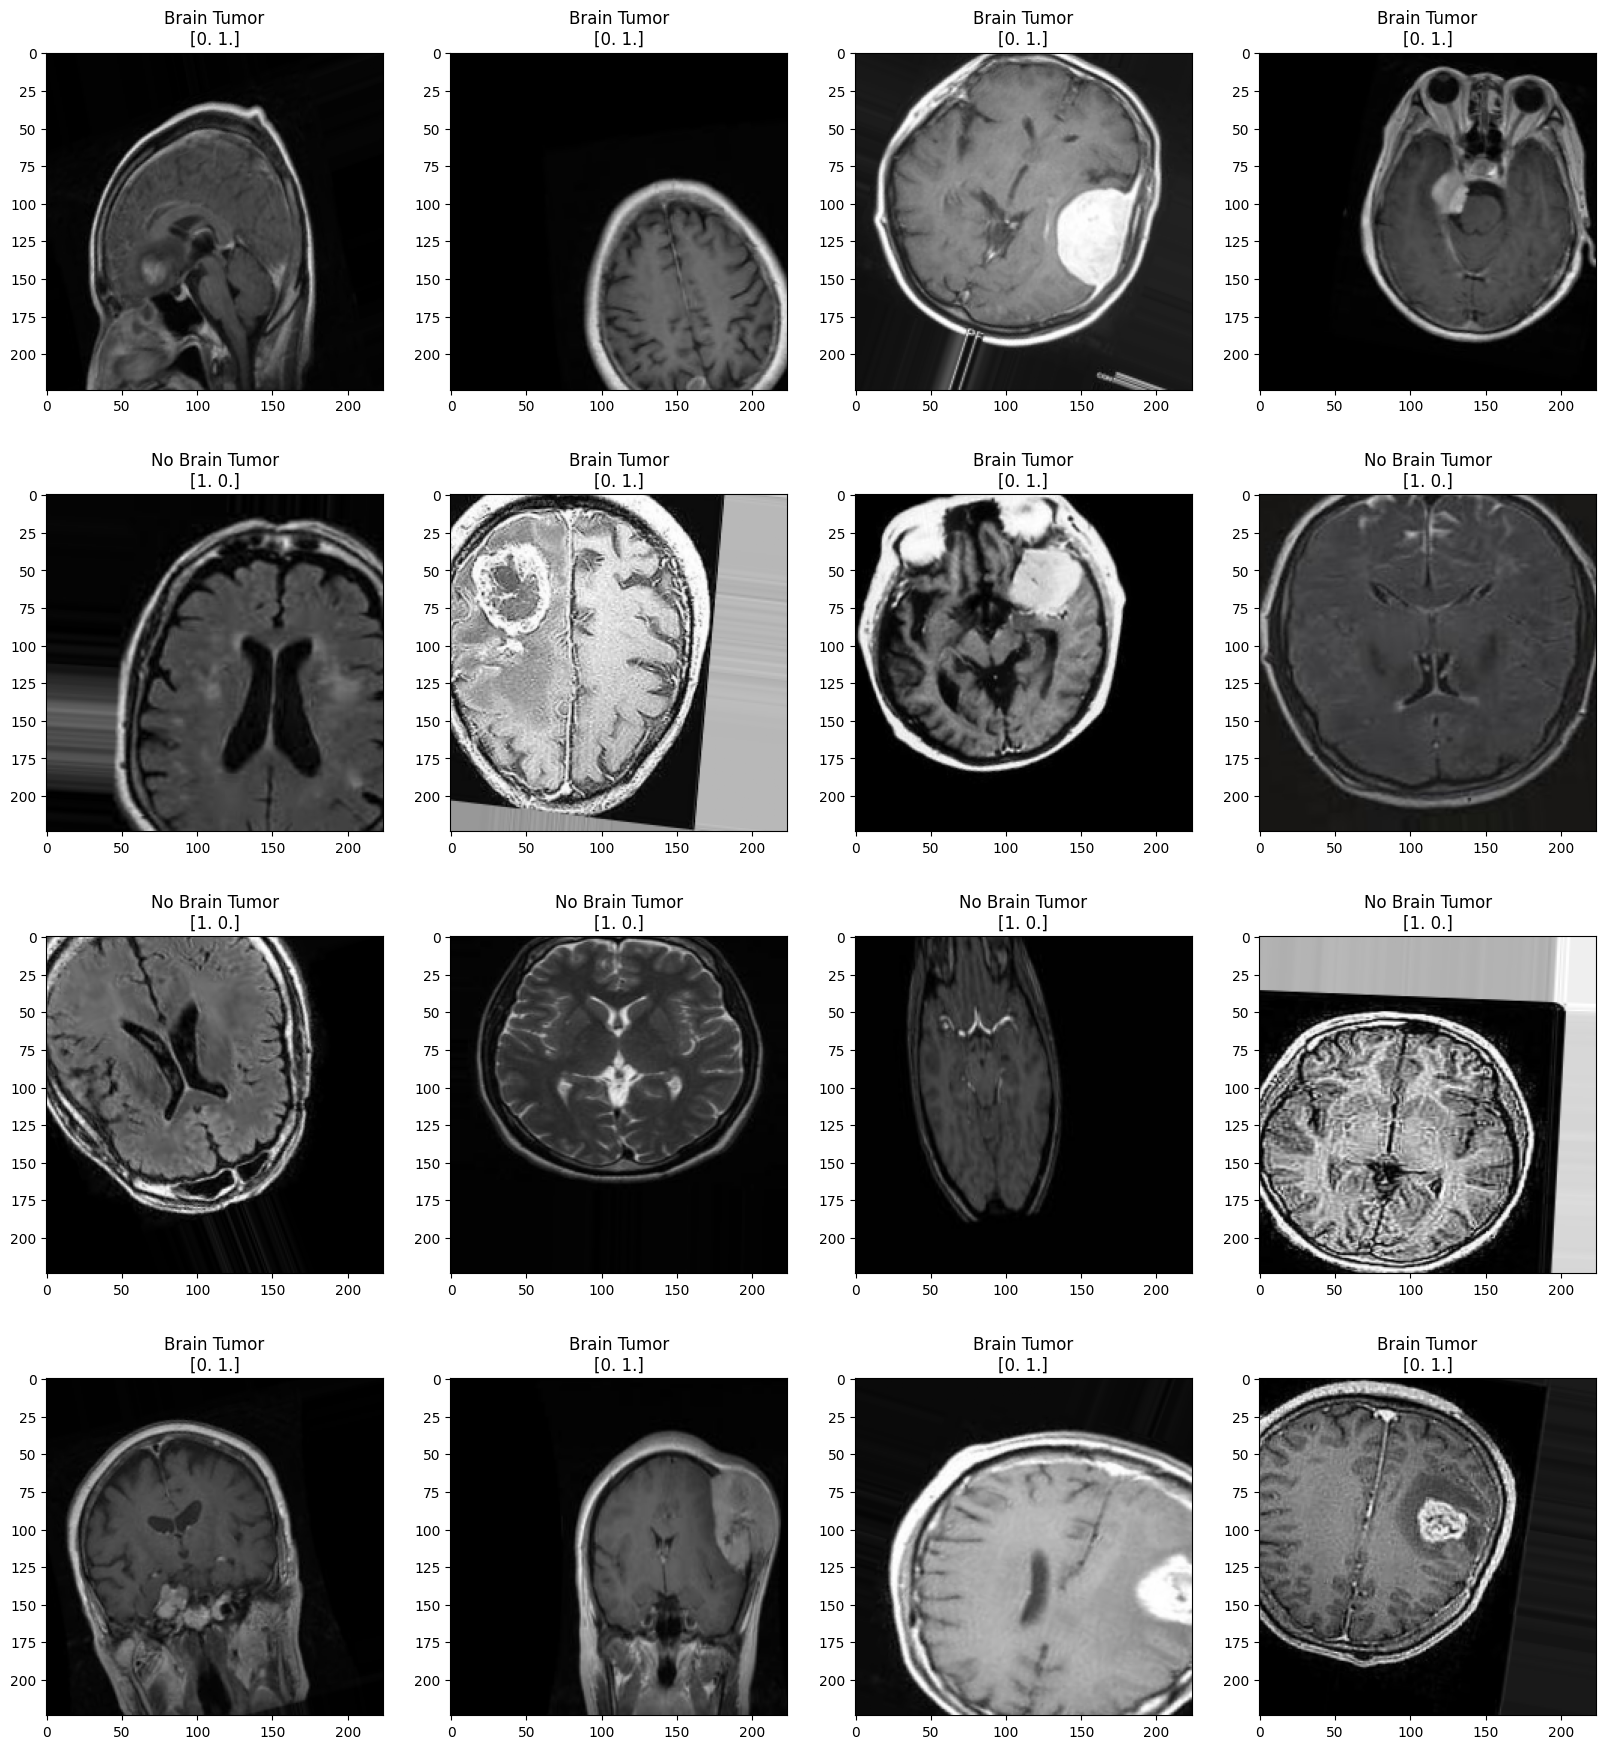

In [18]:
class_name = {0:'No Brain Tumor', 1:'Brain Tumor'}

trainiter = iter(traindata)
images,labels = next(trainiter)

print(labels.shape)
print(images.shape)
print(type(labels))
print(type(images))

fig,axes = plt.subplots(4,4,figsize=(20,22))
axes = axes.ravel()

for i in range(16):
    axes[i].imshow(images[i],cmap='gray')
    index = np.argmax(labels[i])
    axes[i].set_title(f'{class_name[index]}\n{labels[i]}')

plt.show()

In [19]:
# Traning the model with VGG16

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Load the VGG16 base model (pre-trained on ImageNet)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers (for transfer learning)
for layer in base_model.layers:
    layer.trainable = False

# Add your custom classifier on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(traindata.num_classes, activation='softmax')(x)

# Define the model
model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Set up callbacks (same as before)
checkpoint = ModelCheckpoint(
    'vgg16_brain_tumor_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Create test data generator
test_datagen = ImageDataGenerator(rescale=1./255) # Only rescale for test data
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False # Do not shuffle test data
)


# Train the model (same data generators as before)
history = model.fit(
    traindata,
    validation_data=valdata,
    epochs=20,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

# Evaluate
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Save final model
model.save('VGG16_Brain_Tumor_Final.keras')
print("Model saved successfully")

Found 193 images belonging to 2 classes.
Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.5325 - loss: 0.7282
Epoch 1: val_accuracy improved from -inf to 0.76237, saving model to vgg16_brain_tumor_best.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 104s 866ms/step - accuracy: 0.5328 - loss: 0.7279 - val_accuracy: 0.7624 - val_loss: 0.5774
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.6677 - loss: 0.6063
Epoch 2: val_accuracy did not improve from 0.76237
113/113 ━━━━━━━━━━━━━━━━━━━━ 94s 832ms/step - accuracy: 0.6678 - loss: 0.6062 - val_accuracy: 0.7510 - val_loss: 0.5332
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.7264 - loss: 0.5565
Epoch 3: val_accuracy improved from 0.76237 to 0.79461, saving model to vgg16_brain_tumor_best.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 93s 829ms/step - accuracy: 0.7265 - loss: 0.5564 - val_accuracy: 0.7946 - val_loss: 0.4909
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.7587 - loss: 0.5

## Model Selection & Suitability

We selected **VGG16 (a Convolutional Neural Network)** as our base model because it is:
- Pre-trained on **ImageNet**, allowing **transfer learning** for small medical datasets.
- Known for strong **feature extraction** ability in **image classification tasks** like tumor detection.
- Provides a good balance between **accuracy** and **computational cost** compared to deeper networks like ResNet or Inception.


In [20]:
# Automatically saves model best accuracy value so far
modelcheckpoint = ModelCheckpoint('model.keras', monitor = 'val_accuracy', save_best_only = True, mode = 'max', verbose = 1)

# Learning Rate Scheduler (Cosine Annealing)
def scheduler(epoch, lr):
    return 0.001 * (0.5 ** (epoch // 10))

lr_scheduler = LearningRateScheduler(scheduler)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 251ms/step
              precision    recall  f1-score   support

          NO       1.00      0.64      0.78        97
         YES       0.73      1.00      0.85        96

    accuracy                           0.82       193
   macro avg       0.87      0.82      0.81       193
weighted avg       0.87      0.82      0.81       193



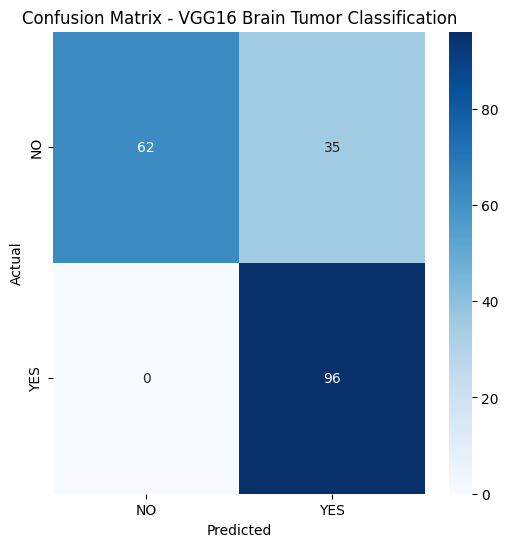

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.7916 - loss: 0.4865


In [21]:
# Parameter Tuning - Frozen Version
# Evaluating Base VGG16 Model (Frozen Layers)
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on test data
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

# Classification report
print(classification_report(test_generator.classes, y_pred, target_names=list(test_generator.class_indices.keys())))

# Confusion Matrix
cm = confusion_matrix(test_generator.classes, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.title('Confusion Matrix - VGG16 Brain Tumor Classification')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

base_acc = model.evaluate(test_generator)[1]

In [22]:
# Fine-Tuning Version
# Fine-Tuning Top VGG16 Layers
# Unfreeze top 4 layers for fine-tuning
for layer in base_model.layers[-4:]:
    layer.trainable = True

model.compile( optimizer=Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=['accuracy'])

history_finetune = model.fit( traindata, validation_data=valdata, epochs=10, verbose=1)

fine_acc = model.evaluate(test_generator)[1]

Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 103s 862ms/step - accuracy: 0.8779 - loss: 0.2984 - val_accuracy: 0.9113 - val_loss: 0.2326
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 93s 822ms/step - accuracy: 0.9185 - loss: 0.2080 - val_accuracy: 0.9452 - val_loss: 0.1548
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 93s 819ms/step - accuracy: 0.9443 - loss: 0.1572 - val_accuracy: 0.9544 - val_loss: 0.1312
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 93s 823ms/step - accuracy: 0.9583 - loss: 0.1254 - val_accuracy: 0.9686 - val_loss: 0.0994
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 92s 819ms/step - accuracy: 0.9668 - loss: 0.1062 - val_accuracy: 0.9700 - val_loss: 0.0958
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 92s 816ms/step - accuracy: 0.9717 - loss: 0.0934 - val_accuracy: 0.9767 - val_loss: 0.0805
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 93s 826ms/step - accuracy: 0.9744 - loss: 0.0841 - val_accuracy: 0.9758 - val_loss: 0.0756
Epoch 8/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 92s 820ms/step - accuracy: 0.9753 - loss: 

In [23]:
# Higher Learning Rate Version
# Training with Learning Rate = 0.0005
# Rebuild model quickly with higher LR (no fine-tuning)
base_model_2 = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model_2.layers:
    layer.trainable = False

x = base_model_2.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
out = Dense(traindata.num_classes, activation='softmax')(x)
model_lr = Model(inputs=base_model_2.input, outputs=out)

model_lr.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])

history_lr = model_lr.fit( traindata, validation_data=valdata, epochs=10, verbose=1)

lr_acc = model_lr.evaluate(test_generator)[1]

Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 97s 836ms/step - accuracy: 0.5815 - loss: 0.6819 - val_accuracy: 0.7932 - val_loss: 0.4713
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 91s 810ms/step - accuracy: 0.7998 - loss: 0.4686 - val_accuracy: 0.8285 - val_loss: 0.4017
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 91s 806ms/step - accuracy: 0.8238 - loss: 0.4089 - val_accuracy: 0.8644 - val_loss: 0.3550
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 91s 810ms/step - accuracy: 0.8364 - loss: 0.3767 - val_accuracy: 0.8585 - val_loss: 0.3409
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 91s 808ms/step - accuracy: 0.8475 - loss: 0.3581 - val_accuracy: 0.8677 - val_loss: 0.3225
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 91s 804ms/step - accuracy: 0.8613 - loss: 0.3354 - val_accuracy: 0.8749 - val_loss: 0.3049
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 92s 816ms/step - accuracy: 0.8481 - loss: 0.3351 - val_accuracy: 0.8822 - val_loss: 0.2888
Epoch 8/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.8747 - loss: 0.2

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 243ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 244ms/step

 Evaluation Report for VGG16 Frozen
              precision    recall  f1-score   support

          NO       0.99      0.90      0.94        97
         YES       0.90      0.99      0.95        96

    accuracy                           0.94       193
   macro avg       0.95      0.94      0.94       193
weighted avg       0.95      0.94      0.94       193



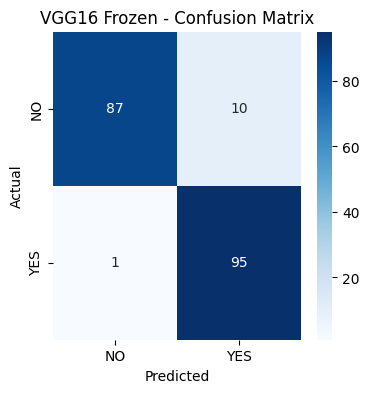


 Evaluation Report for VGG16 Fine-tuned
              precision    recall  f1-score   support

          NO       0.99      0.90      0.94        97
         YES       0.90      0.99      0.95        96

    accuracy                           0.94       193
   macro avg       0.95      0.94      0.94       193
weighted avg       0.95      0.94      0.94       193



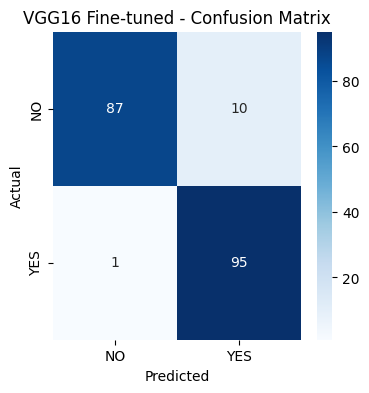


 Evaluation Report for VGG16 (LR tuned)
              precision    recall  f1-score   support

          NO       1.00      0.64      0.78        97
         YES       0.73      1.00      0.85        96

    accuracy                           0.82       193
   macro avg       0.87      0.82      0.81       193
weighted avg       0.87      0.82      0.81       193



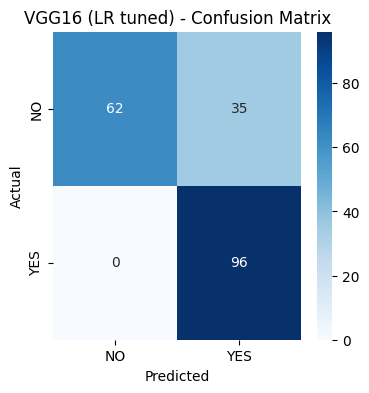

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(y_true, y_pred, model_name, target_names):
    print(f"\n Evaluation Report for {model_name}")
    print(classification_report(y_true, y_pred, target_names=target_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Get true labels from the test generator
y_true = test_generator.classes

# Predict on test data for each model
# Assuming you have already defined model, model (fine-tuned), and model_lr from previous cells
Y_pred_frozen = model.predict(test_generator) # Use the 'model' which was trained with frozen layers
y_pred_frozen = np.argmax(Y_pred_frozen, axis=1)

Y_pred_finetuned = model.predict(test_generator) # Use the 'model' which was fine-tuned
y_pred_finetuned = np.argmax(Y_pred_finetuned, axis=1)

Y_pred_lr = model_lr.predict(test_generator) # Use the 'model_lr' trained with higher LR
y_pred_lr = np.argmax(Y_pred_lr, axis=1)


# Evaluate all three models
target_names = list(test_generator.class_indices.keys())
evaluate_model(y_true, y_pred_frozen, "VGG16 Frozen", target_names)
evaluate_model(y_true, y_pred_finetuned, "VGG16 Fine-tuned", target_names)
evaluate_model(y_true, y_pred_lr, "VGG16 (LR tuned)", target_names)

## Model Variations
We implemented **three variations** of VGG16 to analyze performance:

| Version | Description | Key Change |
|----------|--------------|------------|
| **Frozen** | Used VGG16 as a fixed feature extractor (all convolutional layers frozen) | Only fully connected layers trained |
| **Fine-tuned** | Unfroze top few convolutional layers | Allowed more learning for domain-specific features |
| **LR (Learning Rate)** | Tuned different learning rates (0.001, 0.0001, etc.) | Observed optimizer sensitivity |

In [27]:
# Comparison Table

print("Model Comparison Summary")

comparison = pd.DataFrame({'Model_Version': ['VGG16_Frozen', 'VGG16_FineTuned', 'VGG16_LR_0.0005'], 'Accuracy': [base_acc, fine_acc, lr_acc]})
print(comparison)

Model Comparison Summary
     Model_Version  Accuracy
0     VGG16_Frozen  0.818653
1  VGG16_FineTuned  0.943005
2  VGG16_LR_0.0005  0.818653


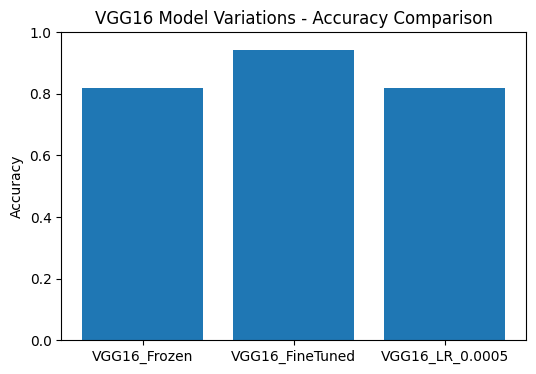

Best Performing Model: VGG16_FineTuned with Accuracy = 0.9430


In [28]:
# Visualize Accuracy Comparison
plt.figure(figsize=(6,4))
plt.bar(comparison['Model_Version'], comparison['Accuracy'])
plt.title('VGG16 Model Variations - Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.show()

# Final Conclusion
best_model = comparison.loc[comparison['Accuracy'].idxmax()]
print(f"Best Performing Model: {best_model['Model_Version']} with Accuracy = {best_model['Accuracy']:.4f}")

- Fine-tuning improved accuracy and recall, showing that letting the CNN adapt to medical images enhances discrimination between tumor and non-tumor regions.
- The frozen model was reliable but less accurate, indicating generic ImageNet features were not fully optimal.
- Learning rate tuning helped stabilize training and reduce overfitting.

##Conclusion:
The **Fine-tuned VGG16** variant achieved the **best balance of performance** and generalization, making it the most suitable model for brain tumor classification.